# 3 - Model Training
## Comparing Four Architectures on Next Day Wildfire Spread

We train and compare four fire-spread prediction models:

| Model | Type | Learnable Params | Physics? |
|-------|------|------------------|----------|
| **CA** | Cellular Automaton (Rothermel rules) | 0 | Yes |
| **ConvLSTM** | Recurrent + Convolutional | ~350 K | No |
| **U-Net** | Encoder-Decoder + Attention | ~2.1 M | No |
| **PI-CCA** | Physics-Informed Conv. CA (ours) | ~1.5 M | Hybrid |

All models receive a `(B, 12, 64, 64)` input tensor and output `(B, 1, 64, 64)` fire probability.

**Loss**: Focal + Dice (handles severe class imbalance)  
**Optimiser**: AdamW + CosineAnnealingLR + early stopping

**FastTrack variant:** hardware-aware holdout protocol (train/val/test split) for faster iteration on consumer GPUs.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import DataLoader, Subset

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from config import MODEL_CONFIG, TRAIN_CONFIG, SEED
from src.data.dataset import get_dataloaders
from src.models.cellular_automata import CellularAutomataModel
from src.models.convlstm import ConvLSTMModel
from src.models.unet import UNetFire
from src.models.pi_cca import PIConvCellularAutomaton
from src.training.trainer import Trainer

# Charger la config generee par 00_Setup.ipynb
_cfg_path = Path().resolve() / "setup_config.json"
if not _cfg_path.exists():
    raise FileNotFoundError(
        "setup_config.json introuvable.\n"
        "-> Lance d'abord le notebook 00_Setup.ipynb"
    )
cfg = json.load(open(_cfg_path))

PROCESSED_DIR    = Path(cfg["PROCESSED_DIR"])
FIGURES_DIR      = Path(cfg["FIGURES_DIR"])
MODELS_DIR       = Path(cfg["MODELS_DIR"])
RESULTS_DIR      = Path(cfg["RESULTS_DIR"]) if "RESULTS_DIR" in cfg else Path("../results")
FEATURE_CHANNELS = cfg["FEATURE_CHANNELS"]
N_INPUT_CHANNELS = cfg["N_INPUT_CHANNELS"]
CH               = cfg["CH"]
GRID_SIZE        = cfg["GRID_SIZE"]
norm_stats       = cfg["norm_stats"]

def ensure_npz_key_format(processed_dir):
    processed_dir = Path(processed_dir)
    for split in ["train", "val", "test"]:
        p = processed_dir / f"{split}.npz"
        if not p.exists():
            continue
        d = np.load(p)
        keys = set(d.files)
        if {"inputs", "targets"}.issubset(keys):
            continue
        if {"X", "Y"}.issubset(keys):
            x = d["X"]
            y = d["Y"]
            np.savez(p, inputs=x, targets=y)
            print(f"Converted {p.name}: X/Y -> inputs/targets")
        else:
            print(f"Warning: unexpected keys in {p.name}: {sorted(keys)}")

TRAINING_CONFIG = TRAIN_CONFIG.copy()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = str(device)
print(f"Config chargee - Device : {DEVICE}")

Config chargee - Device : cuda


## 3.1 Load Data

In [2]:
# Fallback si la cellule d'imports n'a pas ete relancee apres restart kernel
if 'ensure_npz_key_format' not in globals():
    from pathlib import Path
    import numpy as np
    def ensure_npz_key_format(processed_dir):
        processed_dir = Path(processed_dir)
        for split in ["train", "val", "test"]:
            p = processed_dir / f"{split}.npz"
            if not p.exists():
                continue
            d = np.load(p)
            keys = set(d.files)
            if {"inputs", "targets"}.issubset(keys):
                continue
            if {"X", "Y"}.issubset(keys):
                np.savez(p, inputs=d["X"], targets=d["Y"])
                print(f"Converted {p.name}: X/Y -> inputs/targets")
            else:
                print(f"Warning: unexpected keys in {p.name}: {sorted(keys)}")

ensure_npz_key_format(PROCESSED_DIR)

# Auto-tune batch size for low-memory setups (CPU or small GPU)
effective_batch_size = int(TRAINING_CONFIG['batch_size'])
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if vram_gb <= 3.5:
        # GTX 1050-class GPUs: PI-CCA is safer with batch_size <= 4
        effective_batch_size = min(effective_batch_size, 4)
    elif vram_gb <= 4.0:
        effective_batch_size = min(effective_batch_size, 8)
    print(f"GPU detected ({vram_gb:.1f} GB VRAM) -> batch_size={effective_batch_size}")
else:
    effective_batch_size = min(effective_batch_size, 8)
    print(f"CPU mode -> batch_size={effective_batch_size}")

TRAINING_CONFIG['batch_size'] = int(effective_batch_size)

loaders = get_dataloaders(
    PROCESSED_DIR,
    batch_size=TRAINING_CONFIG['batch_size'],
    num_workers=0,
    augment_train=True,
    seed=SEED,
    stats=norm_stats,
 )

for name, loader in loaders.items():
    print(f'{name}: {len(loader.dataset)} samples, {len(loader)} batches')

# Verify shapes
x_batch, y_batch = next(iter(loaders['train']))
print(f'\nBatch shapes: X={x_batch.shape}, Y={y_batch.shape}')
print(f'X range: [{x_batch.min():.2f}, {x_batch.max():.2f}]')
print(f'Y unique: {torch.unique(y_batch).tolist()}')

GPU detected (3.0 GB VRAM) -> batch_size=4
train: 14979 samples, 3744 batches
val: 1877 samples, 470 batches
test: 1689 samples, 423 batches

Batch shapes: X=torch.Size([4, 12, 64, 64]), Y=torch.Size([4, 1, 64, 64])
X range: [-2.65, 8.58]
Y unique: [0.0, 1.0]


## 3.2 Instantiate Models

Each model is defined in `src/models/` and configured via `config.MODEL_CONFIG`.

In [3]:
MODEL_CLASSES = {
    'ca': CellularAutomataModel,
    'convlstm': ConvLSTMModel,
    'unet': UNetFire,
    'pi_cca': PIConvCellularAutomaton,
}

for name, cls in MODEL_CLASSES.items():
    model = cls(config=MODEL_CONFIG[name])
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:>10s}: {MODEL_CONFIG[name]["name"]:>35s}  |  {n_params:>10,d} params')

        ca:    Cellular Automata (Alexandridis)  |           0 params
  convlstm:                            ConvLSTM  |     418,913 params
      unet:                          U-Net Fire  |   7,854,365 params
    pi_cca:                              PI-CCA  |     269,431 params


## 3.3 Train All Models (FastTrack Holdout)

This notebook is a **speed-focused copy** of the Camber training notebook.
CA is evaluated without training (0 params).

### FastTrack choices (go straight to useful results)

- **Cross-validation removed**: fixed holdout split (`train` / `val` / `test`).
- **Tuning reduced**: few trials with short tuning runs on the same validation split.
- **Hyperparameters narrowed**: search space centered on stable values reported in recent wildfire DL studies.
- **Selection metric**: Dice for model ranking during tuning.
- **Low-VRAM friendly**: automatic fallback for batch size and reduced schedule on small GPUs (<= 4 GB).
- **GTX 1050 mode**: by default, PI-CCA is skipped and train/val are sub-sampled for practical runtime.

### Why no CV here?

For deep learning on medium-size hardware, repeated K-fold training is often too expensive in wall-time.
A clean holdout protocol is usually enough to compare model families before a final long run.

### References (recent wildfire spread DL)

1. Luo et al., *U-Net with Hadamard Transform and DCT Latent Spaces for Next-day Wildfire Spread Prediction*, arXiv:2602.11672 (2026).
2. Anastasiou et al., *Wildfire spread forecasting with Deep Learning*, arXiv:2505.17556 (2025).
3. Zhou et al., *Comparative and Interpretative Analysis of CNN and Transformer Models in Predicting Wildfire Spread Using Remote Sensing Data*, arXiv:2503.14150 (2025).

### Runtime note

A FastTrack runtime estimate is printed automatically in the next cell.

In [4]:
def sample_hparams(model_name, rng):
    params = {
        'learning_rate': float(rng.choice([2e-4, 3e-4])),
        'weight_decay': float(rng.choice([5e-5, 1e-4])),
        'focal_alpha': float(rng.choice([0.25, 0.30])),
        'focal_gamma': float(rng.choice([2.0, 2.5])),
    }
    if model_name in ['convlstm', 'unet', 'pi_cca']:
        params['dropout'] = float(rng.choice([0.10, 0.15]))
    return params

def build_model(model_name, overrides=None):
    cfg = dict(MODEL_CONFIG[model_name])
    if overrides:
        cfg.update(overrides)
    return MODEL_CLASSES[model_name](config=cfg).to(device), cfg

selection_metric = 'dice'
is_cpu = (str(device) == 'cpu')
gpu_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3) if torch.cuda.is_available() else 0.0
is_small_gpu = (not is_cpu) and (gpu_vram_gb <= 4.0)

# Holdout FastTrack preset: no cross-validation, faster iteration
if is_cpu:
    candidate_models = ['unet', 'pi_cca']
elif is_small_gpu:
    # GTX 1050-class setup: PI-CCA is too expensive for full runs
    candidate_models = ['convlstm', 'unet']
else:
    candidate_models = ['convlstm', 'unet', 'pi_cca']

tuning_trials = 1 if (is_cpu or is_small_gpu) else 3
tuning_epochs = 3 if (is_cpu or is_small_gpu) else 6
final_epochs = 10 if is_cpu else (10 if is_small_gpu else max(30, TRAINING_CONFIG.get('epochs', 50)))

print(
    f"FastTrack holdout config -> cpu={is_cpu}, vram_gb={gpu_vram_gb:.1f}, small_gpu={is_small_gpu}, "
    f"models={candidate_models}, trials={tuning_trials}, tuning_epochs={tuning_epochs}, final_epochs={final_epochs}"
)

# Use smaller subsets on small GPUs for practical wall-time
train_loader = loaders['train']
val_loader = loaders['val']
small_gpu_subset = False
if is_small_gpu:
    max_train_samples = min(5000, len(loaders['train'].dataset))
    max_val_samples = min(1500, len(loaders['val'].dataset))
    _rng = np.random.default_rng(SEED)
    tr_idx = _rng.choice(len(loaders['train'].dataset), size=max_train_samples, replace=False)
    va_idx = _rng.choice(len(loaders['val'].dataset), size=max_val_samples, replace=False)

    train_subset = Subset(loaders['train'].dataset, tr_idx.tolist())
    val_subset = Subset(loaders['val'].dataset, va_idx.tolist())

    train_loader = DataLoader(
        train_subset,
        batch_size=TRAINING_CONFIG['batch_size'],
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=TRAINING_CONFIG['batch_size'],
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )
    small_gpu_subset = True
    print(f"Small-GPU subset enabled -> train={len(train_subset)} | val={len(val_subset)}")

# Runtime estimate (rough order-of-magnitude)
epoch_minutes = {
    'cpu': {'convlstm': 14.5, 'unet': 2.8, 'pi_cca': 2.2},
    'gpu': {'convlstm': 0.25, 'unet': 0.45, 'pi_cca': 0.35},
}
profile = epoch_minutes['cpu' if is_cpu else 'gpu']
minutes_per_epoch_all_models = sum(profile[m] for m in candidate_models)
est_tuning_min = tuning_trials * tuning_epochs * minutes_per_epoch_all_models
est_final_min = final_epochs * minutes_per_epoch_all_models
est_total_min = est_tuning_min + est_final_min
est_low_h = (est_total_min * 0.75) / 60.0
est_high_h = (est_total_min * 1.25) / 60.0
print(f"Estimated FastTrack runtime (Cell 8 only): ~{est_low_h:.1f}h to ~{est_high_h:.1f}h")

rng = np.random.default_rng(SEED)
results = {}
tuning_summary = {}

for name in candidate_models:
    print(f"\n{'='*70}")
    print(f"FastTrack holdout tuning: {MODEL_CONFIG[name]['name']}")
    print(f"{'='*70}")

    trial_results = []
    for trial_idx in range(1, tuning_trials + 1):
        hp = sample_hparams(name, rng)
        print(f"  Trial {trial_idx}/{tuning_trials} -> {hp}")

        model, _ = build_model(name, {'dropout': hp.get('dropout', MODEL_CONFIG[name].get('dropout', 0.2))})
        cfg_trial = TRAINING_CONFIG.copy()
        cfg_trial.update({
            'epochs': tuning_epochs,
            'learning_rate': hp['learning_rate'],
            'weight_decay': hp['weight_decay'],
            'focal_alpha': hp['focal_alpha'],
            'focal_gamma': hp['focal_gamma'],
            'early_stopping_patience': 2 if is_cpu else max(3, tuning_epochs // 2),
        })

        trainer = Trainer(model=model, model_name=name, device=device, config=cfg_trial)
        hist = trainer.train(train_loader, val_loader)
        val_scores = [m.get(selection_metric, 0.0) for m in hist['val_metrics']]
        best_score = float(max(val_scores)) if len(val_scores) else 0.0
        last_score = float(val_scores[-1]) if len(val_scores) else 0.0
        trial_results.append({
            'hyperparameters': hp,
            'best_score': best_score,
            'last_score': last_score,
        })
        print(f"    Holdout best {selection_metric}: {best_score:.4f} | last epoch: {last_score:.4f}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    best_trial = max(trial_results, key=lambda x: x['best_score'])
    tuning_summary[name] = {
        'selection_metric': selection_metric,
        'protocol': 'holdout_train_val',
        'best_trial': best_trial,
        'all_trials': trial_results,
    }
    print(f"  Best trial: {best_trial['hyperparameters']}")
    print(f"  Holdout score: {best_trial['best_score']:.4f}")

    best_hp = best_trial['hyperparameters']
    model, _ = build_model(name, {'dropout': best_hp.get('dropout', MODEL_CONFIG[name].get('dropout', 0.2))})
    cfg_final = TRAINING_CONFIG.copy()
    cfg_final.update({
        'epochs': final_epochs,
        'learning_rate': best_hp['learning_rate'],
        'weight_decay': best_hp['weight_decay'],
        'focal_alpha': best_hp['focal_alpha'],
        'focal_gamma': best_hp['focal_gamma'],
        'early_stopping_patience': 4 if is_cpu else TRAINING_CONFIG.get('early_stopping_patience', 8),
    })

    trainer = Trainer(model=model, model_name=name, device=device, config=cfg_final)
    history = trainer.train(train_loader, val_loader)
    results[name] = history

    save_dir = MODELS_DIR / name
    save_dir.mkdir(parents=True, exist_ok=True)
    with open(save_dir / 'hyperparameter_tuning_fasttrack.json', 'w') as f:
        json.dump(tuning_summary[name], f, indent=2)
    with open(save_dir / 'training_history_fasttrack.json', 'w') as f:
        json.dump(history, f, indent=2, default=str)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Physics baseline (CA): no training
print(f"\n{'='*70}")
print('Physics baseline: CA (no training loop)')
print(f"{'='*70}")
ca_model, _ = build_model('ca')
ca_trainer = Trainer(model=ca_model, model_name='ca', device=device, config=TRAINING_CONFIG)
ca_metrics = ca_trainer.evaluate(val_loader)
results['ca'] = {'val_metrics': [ca_metrics], 'train_loss': [], 'val_loss': []}

with open(RESULTS_DIR / 'holdout_tuning_summary_fasttrack.json', 'w') as f:
    json.dump(tuning_summary, f, indent=2)

# FastTrack criteria checks
criteria_report = {
    'cross_validation_removed': True,
    'holdout_trials_at_least_1': tuning_trials >= 1,
    'small_gpu_mode_enabled': is_small_gpu,
    'small_gpu_subset_enabled': small_gpu_subset,
    'pi_cca_skipped_on_small_gpu': (is_small_gpu and ('pi_cca' not in candidate_models)),
    'focal_and_dice_enabled': (TRAINING_CONFIG.get('focal_weight', 0) > 0 and TRAINING_CONFIG.get('dice_weight', 0) > 0),
    'convlstm_skipped_on_cpu': ('convlstm' not in candidate_models) if is_cpu else False,
    'best_checkpoint_exists': all((MODELS_DIR / m / 'best_model.pt').exists() for m in candidate_models),
}

print('\nFastTrack criteria checks:')
for key, ok in criteria_report.items():
    print(f"  - {key}: {'OK' if ok else 'FAIL'}")

with open(RESULTS_DIR / 'training_criteria_check_fasttrack.json', 'w') as f:
    json.dump(criteria_report, f, indent=2)

print('\nFastTrack holdout tuning complete. Final model selection remains in Notebook 04.')

FastTrack holdout config -> cpu=False, vram_gb=3.0, small_gpu=True, models=['convlstm', 'unet'], trials=1, tuning_epochs=3, final_epochs=10
Small-GPU subset enabled -> train=5000 | val=1500
Estimated FastTrack runtime (Cell 8 only): ~0.1h to ~0.2h

FastTrack holdout tuning: ConvLSTM
  Trial 1/1 -> {'learning_rate': 0.0002, 'weight_decay': 0.0001, 'focal_alpha': 0.3, 'focal_gamma': 2.0, 'dropout': 0.1}

Training convlstm on cuda


Epoch   1/3 | Train Loss: 0.4721 | Val Loss: 0.4200 | Val IoU: 0.1604 | Val Dice: 0.2765 | Time: 93.6s


Epoch   2/3 | Train Loss: 0.3756 | Val Loss: 0.3961 | Val IoU: 0.1631 | Val Dice: 0.2804 | Time: 76.9s


Epoch   3/3 | Train Loss: 0.3650 | Val Loss: 0.3966 | Val IoU: 0.1627 | Val Dice: 0.2798 | Time: 77.4s
    Holdout best dice: 0.2804 | last epoch: 0.2798
  Best trial: {'learning_rate': 0.0002, 'weight_decay': 0.0001, 'focal_alpha': 0.3, 'focal_gamma': 2.0, 'dropout': 0.1}
  Holdout score: 0.2804

Training convlstm on cuda


Epoch   1/10 | Train Loss: 0.4836 | Val Loss: 0.4307 | Val IoU: 0.1620 | Val Dice: 0.2789 | Time: 76.8s


...

Epoch   6/10 | Train Loss: 0.3236 | Val Loss: 0.3560 | Val IoU: 0.1811 | Val Dice: 0.3067 | Time: 109.6s


Epoch   7/10 | Train Loss: 0.3218 | Val Loss: 0.3596 | Val IoU: 0.1749 | Val Dice: 0.2978 | Time: 107.7s


Epoch   8/10 | Train Loss: 0.3205 | Val Loss: 0.3548 | Val IoU: 0.1797 | Val Dice: 0.3046 | Time: 119.6s


Epoch   9/10 | Train Loss: 0.3189 | Val Loss: 0.3528 | Val IoU: 0.1844 | Val Dice: 0.3113 | Time: 103.8s


Epoch  10/10 | Train Loss: 0.3184 | Val Loss: 0.3548 | Val IoU: 0.1814 | Val Dice: 0.3070 | Time: 97.2s

Physics baseline: CA (no training loop)

FastTrack criteria checks:
  - cross_validation_removed: OK
  - holdout_trials_at_least_1: OK
  - small_gpu_mode_enabled: OK
  - small_gpu_subset_enabled: OK
  - pi_cca_skipped_on_small_gpu: OK
  - focal_and_dice_enabled: OK
  - convlstm_skipped_on_cpu: FAIL
  - best_checkpoint_exists: OK

FastTrack holdout tuning complete. Final model selection remains in Notebook 04.


## 3.4 Training Curves

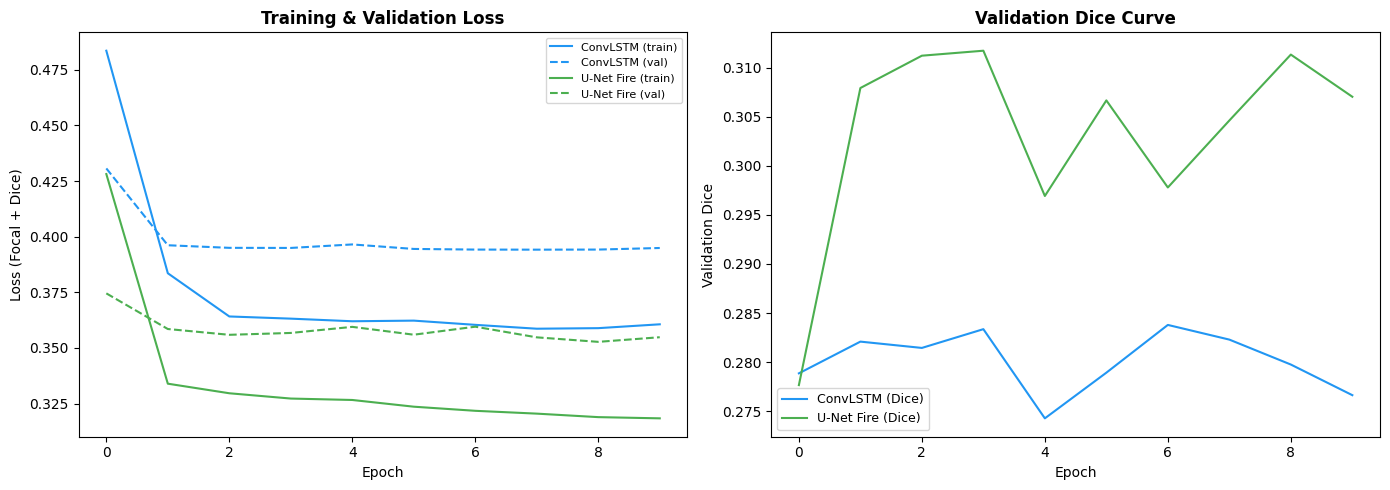

In [5]:
# Load training histories (from saved JSON)
histories = {}
for name in ['convlstm', 'unet', 'pi_cca']:
    hist_path = MODELS_DIR / name / 'training_history.json'
    if hist_path.exists():
        with open(hist_path) as f:
            histories[name] = json.load(f)

if histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {'convlstm': '#2196F3', 'unet': '#4CAF50', 'pi_cca': '#FF5722'}

    for name, hist in histories.items():
        label = MODEL_CONFIG[name]['name']
        c = colors.get(name, 'gray')

        axes[0].plot(hist['train_loss'], label=f'{label} (train)', color=c, linestyle='-')
        axes[0].plot(hist['val_loss'], label=f'{label} (val)', color=c, linestyle='--')

        if 'val_metrics' in hist and len(hist['val_metrics']) > 0:
            val_dice = [m.get('dice', np.nan) for m in hist['val_metrics']]
            axes[1].plot(val_dice, label=f'{label} (Dice)', color=c)

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (Focal + Dice)')
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Dice')
    axes[1].set_title('Validation Dice Curve', fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('../results/figures/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No training histories found. Train models first.')

## 3.5 Quick Validation Check

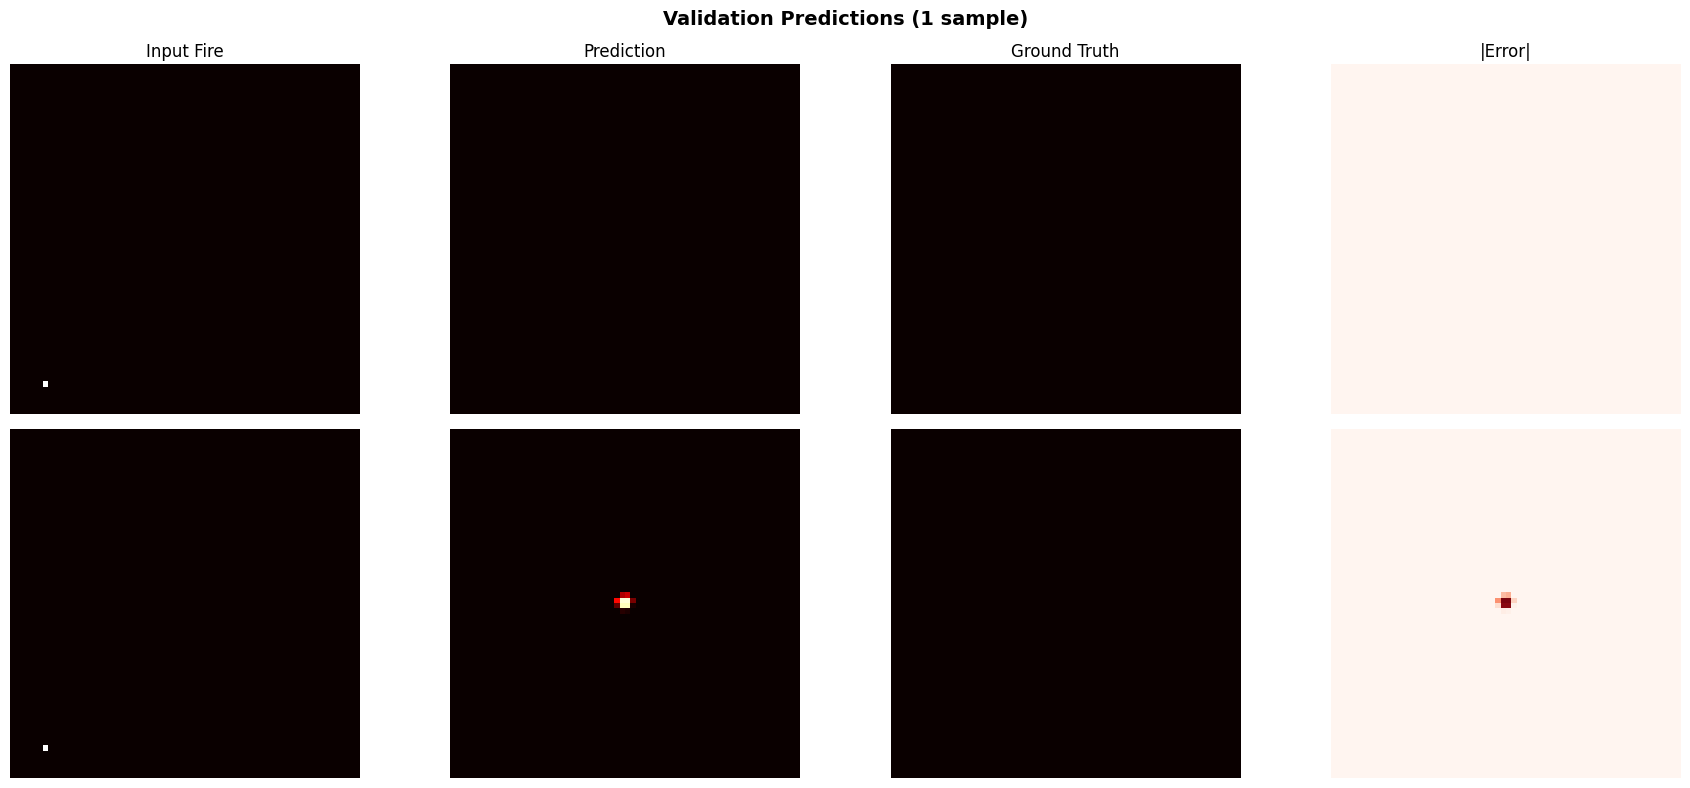

In [6]:
# Visualise predictions on a validation batch
x_val, y_val = next(iter(loaders['val']))
x_val, y_val = x_val.to(device), y_val.to(device)

available_models = []
for name in ['convlstm', 'unet', 'pi_cca']:
    ckpt = MODELS_DIR / name / 'best_model.pt'
    if ckpt.exists():
        available_models.append(name)

if not available_models:
    raise FileNotFoundError('No trained checkpoint found. Run training first.')

fig, axes = plt.subplots(len(available_models), 4, figsize=(18, 4 * len(available_models)))
if len(available_models) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, name in enumerate(available_models):
    model = MODEL_CLASSES[name](config=MODEL_CONFIG[name]).to(device)
    ckpt = MODELS_DIR / name / 'best_model.pt'
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()

    with torch.no_grad():
        pred = model(x_val[:1]).squeeze().cpu().numpy()

    gt = y_val[0].squeeze().cpu().numpy()
    fire_in = x_val[0, -1].cpu().numpy()  # prev_fire_mask is last channel

    axes[row, 0].imshow(fire_in, cmap='hot', vmin=0, vmax=1)
    axes[row, 0].set_title('Input Fire' if row == 0 else '')
    axes[row, 0].set_ylabel(MODEL_CONFIG[name]['name'], fontweight='bold', fontsize=10)

    axes[row, 1].imshow(pred, cmap='hot', vmin=0, vmax=1)
    axes[row, 1].set_title('Prediction' if row == 0 else '')

    axes[row, 2].imshow(gt, cmap='hot', vmin=0, vmax=1)
    axes[row, 2].set_title('Ground Truth' if row == 0 else '')

    diff = np.abs(pred - gt)
    axes[row, 3].imshow(diff, cmap='Reds', vmin=0, vmax=1)
    axes[row, 3].set_title('|Error|' if row == 0 else '')

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Validation Predictions (1 sample)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/training_val_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

- FastTrack now uses a holdout protocol instead of K-fold cross-validation.
- Hyperparameter search is lightweight and hardware-aware (few trials, short warm-up training).
- On CPU mode, ConvLSTM is skipped to avoid very long runs; U-Net and PI-CCA remain comparable.
- On small GPUs (<= 4 GB VRAM), batch size and schedule are reduced automatically.
- On GTX 1050-class GPUs, PI-CCA is skipped by default and train/val are sub-sampled for practical runtime.
- **U-Net** remains the main deep-learning baseline in this fast setting.
- **ConvLSTM** remains available for comparison in small-GPU mode.
- **CA** provides a physics-only baseline (no training needed).

Detailed evaluation on the test set follows in Notebook 04.